# Hyperparameter search for ConvNets with Optuna

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TXSTCODEPLAYGROUND/CodeCS4337Fall2026/blob/main/HyperparameterSearchConvnets/hyperparameter_search_convnets_notebook.ipynb)

This notebook searches the **architecture** of a convolutional network (how many blocks, how wide, how many convolutions per block, BatchNorm, skip connections, dropout) and its **training settings** with [Optuna](https://optuna.org), then trains the best settings found. The network is built from ResNet-like blocks by `HyperparameterSearchConvnets`; the base config is a plain two-block ConvNet. The final training run is logged to Weights & Biases (W&B); the search trials are not, unless you turn it on (section 4).

### Choose your route

| Route | Sections to run | Search and train with |
| --- | --- | --- |
| **Colab, from notebook cells** | 1 (setup), then 2 to 5 | The cells of sections 3 and 5 |
| **Colab, from Colab's terminal** (Colab Pro) | 1 (setup) in the notebook first; 2, 4, and 5 to read and use the results | The terminal commands in sections 3 and 5; the reload cell then loads the study into the notebook |
| **Locally, from this notebook** | Skip 1, start at [**2. The search space**](#2.-The-search-space) | The cells of sections 3 and 5, with the `.venv` as the notebook's kernel |
| **Locally, from your terminal** | None, no notebook needed (optionally 2, 4, and 5 for the plots) | `python -m HyperparameterSearchConvnets.search --config search01.json`, then `python -m HyperparameterSearchConvnets --config search01_best.json`, from the repo root with the `.venv` activated |
| **Colab CLI, for the final training run** | None, no notebook needed | `python -m HyperparameterSearchConvnets.search --config search01.json`, then `python -m HyperparameterSearchConvnets --config search01_best.json` on a Colab runtime opened from your terminal: see [**Training with the Colab CLI**](#Training-with-the-Colab-CLI) |

In Colab, the setup cells are needed even when you search in the terminal: Google Drive can only be mounted, and Colab Secrets only read, from a notebook cell. Locally, set up the repo once first (`.venv`, requirements, and `.env`, see the main README), and open this notebook from the project folder.

In Colab, run the cells from top to bottom:

1. **Set up** the runtime (Colab only): GPU, Google Drive, the repo, and your W&B key.
2. **Look at the search space**: what is searched, in which ranges, and what the network builder makes.
3. **Run the search**: Optuna trains many settings and keeps the best one.
4. **Read the results**: the best trial and Optuna's plots.
5. **Train the best config** and test it.
6. **Look inside the model** with Captum: activation maps and Grad-CAM.

## 1. Setup (Colab)

> **Running locally?** Skip this section: these cells only work in Colab. Jump to [**2. The search space**](#2.-The-search-space).

The same setup as in the other projects' notebooks. First choose a GPU: *Runtime → Change runtime type → GPU*. Then run these cells once per session (and again after the runtime resets): mount Drive, set up the repo, change directory, and load API keys.

Results, including the Optuna study, go to Google Drive, so a search interrupted by a disconnect can be continued (see the tips at the end).

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

In [ ]:
%%bash
set -e

cd /content
if [ -d CodeCS4337Fall2026/.git ]; then
  git -C CodeCS4337Fall2026 pull --ff-only
else
  git clone https://github.com/TXSTCODEPLAYGROUND/CodeCS4337Fall2026.git
fi
cd CodeCS4337Fall2026

# Colab settings: data on the local disk, results in Google Drive.
cp .envcolab .env

# Install only packages Colab does not already have (versions are not pinned).
grep -vE '^\s*(#|$)' requirements.txt \
  | sed -E 's/[<>=!~;[ ].*//' \
  | while read -r pkg; do
      if pip show "$pkg" > /dev/null 2>&1; then
        echo "skip $pkg (already installed)"
      else
        pip install -q "$pkg" && echo "installed $pkg"
      fi
    done

In [ ]:
# The bash cell above cannot change the notebook's working directory, so do it here.
%cd /content/CodeCS4337Fall2026

### Load your W&B key (optional)

Add your key as a Colab **Secret** named `WANDB_API_KEY` (key icon in the left sidebar → *Add new secret*). Never type it into a cell. The cell below loads `.env`, then looks up missing keys in your Secrets, adds them to this notebook's environment, and saves them to `.env` so terminal runs find them too. Without a key, the training run of section 5 is logged to W&B offline and can be uploaded later with `wandb sync`.

In [ ]:
import os
from pathlib import Path

from dotenv import load_dotenv
from google.colab import userdata

ENV_FILE = Path("/content/CodeCS4337Fall2026/.env")
KEYS = ["WANDB_API_KEY"]

if load_dotenv(ENV_FILE):
    print(f"Loaded settings from {ENV_FILE}")
else:
    print(f"No settings in {ENV_FILE}: run the setup cells first")

for key in KEYS:
    if os.getenv(key):
        print(f"{key}: found in .env")
        continue
    try:
        os.environ[key] = userdata.get(key)
    except Exception:  # noqa: BLE001 (Secret not added or access not granted)
        print(f"{key}: not found, W&B will log offline")
        continue
    with ENV_FILE.open("a") as env_file:
        env_file.write(f"\n{key}={os.environ[key]}\n")
    print(f"{key}: loaded from Colab Secrets and saved to .env")

## 2. The search space

This cell makes the project importable (in Colab and locally) and imports its two entry points: `search` runs the Optuna study, `main` trains and tests one config.

In [2]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO = Path("/content/CodeCS4337Fall2026") if IN_COLAB else Path.cwd().parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from HyperparameterSearchConvnets import main
from HyperparameterSearchConvnets.search import search
from HyperparameterSearchConvnets.utils import CONFIGS_DIR

print((CONFIGS_DIR / "search01.json").read_text())

{
  "base_config": "config01.json",
  "study": {
    "n_trials": 30,
    "timeout_minutes": null,
    "seed": 42,
    "train_fraction": 0.25,
    "pruner_startup_trials": 5,
    "pruner_warmup_epochs": 2,
    "log_trials_to_wandb": false
  },
  "search_space": {
    "num_blocks": [2, 8],
    "first_channels": [16, 32, 64, 128, 256],
    "max_channels": 256,
    "convs_per_block": [1, 3],
    "batch_norm": [true, false],
    "skip_connections": [true, false],
    "activation": ["relu", "leaky_relu", "gelu"],
    "dropout": [0.0, 0.5],
    "batch_size": [64, 128, 256],
    "epochs": [5, 15],
    "optimizer": ["adam", "adamw", "sgd", "rmsprop"],
    "lr": [0.0001, 0.1],
    "momentum": [0.5, 0.99],
    "regularization": ["none", "l1", "l2", "l1_l2"],
    "l1": [1e-07, 0.0001],
    "l2": [1e-06, 0.01],
    "scheduler": ["none", "step", "cosine", "plateau"],
    "step_size": [2, 5],
    "gamma": [0.1, 0.7],
    "early_stopping": [true, false],
    "patience": [2, 5]
  }
}



### Where your results go

Run the cell below and look at what it prints: `OUTPUT_DIR` is the folder where **every run of this project is saved**: checkpoints, metrics, plots, and `runs_summary.csv`. It is set in `.env` at the repo root.

- **In Colab** it is in your Google Drive, `/content/drive/MyDrive/CodeCS4337Fall2026/runs` (from `.envcolab`), so your results survive runtime resets. Open *MyDrive → CodeCS4337Fall2026 → runs* in Google Drive to find them later.
- **Locally** it is `runs`, i.e. the `runs/` folder of the repo (relative paths are relative to the repo root).

Each search gets one folder, `<OUTPUT_DIR>/HyperparameterSearchConvnets/<search name>/` (the study, `trials.csv`, the best config), and each training run its own, `<OUTPUT_DIR>/HyperparameterSearchConvnets/<config>/<timestamp>/`.

In [2]:
import os

from dotenv import load_dotenv

# Colab: the copy of .envcolab made by the setup cell. Locally: your own .env.
load_dotenv(REPO / ".env")
!echo "OUTPUT_DIR=$OUTPUT_DIR"
output_dir = REPO / os.getenv("OUTPUT_DIR", "runs")
print(
    f"Runs of this project are saved in: {output_dir / 'HyperparameterSearchConvnets'}"
)

OUTPUT_DIR=runs
Runs of this project are saved in: /home/virgo/Desktop/projects/CodeCS4337Fall2026/runs/HyperparameterSearchConvnets


The search config has three parts:

- `base_config`: the training config every trial starts from. Everything not searched (seed, validation split, W&B project) comes from it.
- `study`: how many trials to run (`n_trials`), an optional time limit (`timeout_minutes`), the sampler's seed, the fraction of the training data each trial uses (`train_fraction`), the pruner settings, and whether trials are logged to W&B.
- `search_space`: a range `[low, high]` or a list of choices for every hyperparameter.

| Hyperparameter | What it controls |
| --- | --- |
| `num_blocks` | Number of blocks, 2 to 8 |
| `first_channels` | Channels of the first block: 16, 32, 64, 128, or 256. The next blocks follow from it (see below) |
| `max_channels` | Not searched: the upper limit of the channels, 256 |
| `convs_per_block` | 3x3 convolutions in every block, 1 to 3 |
| `batch_norm` | BatchNorm after every convolution, or none |
| `skip_connections` | A ResNet skip connection around every block, or none |
| `activation` | ReLU, Leaky ReLU, or GELU |
| `dropout` | Dropout probability at the end of every block |
| `batch_size` | Samples per training step |
| `epochs` | Maximum number of epochs |
| `optimizer`, `lr`, `momentum` | Adam, AdamW, SGD, or RMSprop; the learning rate (searched on a log scale); momentum (SGD and RMSprop only) |
| `regularization`, `l1`, `l2` | No penalty, L1 (pushes weights to zero), L2 (weight decay, shrinks weights), or both, with their weights (log scale) |
| `scheduler`, `step_size`, `gamma` | Constant learning rate, step decay, cosine decay, or reduce-on-plateau, with their settings |
| `early_stopping`, `patience` | Whether to stop when validation accuracy stops improving, and after how many epochs |

**The network is a stack of blocks.** Each block is one or more 3x3 convolutions (with BatchNorm after each one if `batch_norm`), an activation, and dropout. With `skip_connections`, the block's input is added to the output of its last convolution, as in ResNet; a 1x1 convolution adapts the input when the number of channels changes. The first two blocks end with 2x2 max pooling (28x28 → 14x14 → 7x7), and, as in ResNet, the channels double each time the image is halved: `first_channels = 32` with 4 blocks gives `[32, 64, 128, 128]`. A linear layer on the last block's 7x7 feature maps predicts the class. The base config, `config01.json`, is the simplest case: `[32, 64]`, one convolution per block, no BatchNorm, skip connections, or dropout.

Some hyperparameters only exist for some choices, e.g. `momentum` only for SGD and RMSprop. Optuna handles this naturally: the search space is defined by running Python code (`suggest_config` in `search.py`), so an `if` decides what is sampled.

**To change the search**, copy `search01.json` in the file browser (left sidebar, `CodeCS4337Fall2026/HyperparameterSearchConvnets/configs/`), e.g. to `search02.json`, edit it, and pass its name below. To fix a hyperparameter instead of searching it, give a single choice (`["adam"]`) or a range with equal ends (`[10, 10]`). Fewer searched hyperparameters means fewer trials are needed.

### What the builder makes

The cell below builds the base network and a deeper one with every option on, and prints their sizes and one block of the deep network. Deep networks without BatchNorm or skip connections are hard to train: the search shows how much these two help.

In [3]:
from HyperparameterSearchConvnets.models.components import ConvNet, block_channels

networks = {
    "config01 (base)": ConvNet(),
    "6 blocks, 2 convs, BatchNorm, skip": ConvNet(
        block_channels(32, 6), convs_per_block=2, batch_norm=True, skip_connections=True
    ),
}
for name, net in networks.items():
    num_params = sum(p.numel() for p in net.parameters())
    channels = [block.conv_layers[0].out_channels for block in net.blocks]
    print(f"{name}: channels {channels}, {num_params:,} parameters")
print(networks["6 blocks, 2 convs, BatchNorm, skip"].blocks[1])

config01 (base): channels [32, 64], 50,186 parameters
6 blocks, 2 convs, BatchNorm, skip: channels [32, 64, 128, 128, 128, 128], 1,246,602 parameters
ConvBlock(
  (conv_layers): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (shortcut): Sequential(
    (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (activation): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
)


## 3. Run the search

Each trial trains one setting on the training split and is scored by its best **validation** accuracy. The test set is never used during the search: choosing settings by their test score would make that score optimistic.

- Optuna's **TPE sampler** picks each trial's settings from how earlier trials did: after the first random trials, it samples more where the scores were good.
- The **median pruner** stops a trial early when its validation accuracy after an epoch is below the median of earlier trials at the same epoch. Pruned trials save time for promising ones.

ConvNets are slower to train than fully connected networks, and the search also tries deep, wide ones: on a GPU, a trial takes from under a minute to several minutes, so 30 trials take roughly half an hour to a few hours. The median pruner stops many of the weak trials early. Try `N_TRIALS = 3` first to check that everything works. Running the cell again **adds** trials to the same study instead of starting over.

**Faster trials with less data:** `TRAIN_FRACTION` is the fraction of the 54,000 training images each trial trains on. In Colab, which has only 2 CPU cores to load images, `0.25` makes every epoch about 4 times faster. The validation set stays complete, so the scores remain reliable, and the best config is still trained on all the data in section 5. The trade-off: settings that depend on the amount of data (epochs, dropout, L1/L2 strength) may not transfer exactly, so prefer `1.0` when you have the time. Keep the same fraction for all trials of a study; to change it, use a new search config name.

In [4]:
import warnings

# Harmless warnings printed for every trial: Lightning still uses a PyTorch class
# that is being renamed, and Python warns about the DataLoader starting workers.
warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*")
warnings.filterwarnings("ignore", message=r".*use of fork\(\) may lead to deadlocks.*")

SEARCH_CONFIG = "search01.json"
N_TRIALS = 20
TRAIN_FRACTION = 0.25  # e.g. 0.25 in Colab for faster trials

study = search(SEARCH_CONFIG, n_trials=N_TRIALS, train_fraction=TRAIN_FRACTION)

[I 2026-10-03 00:51:32,967] A new study created in RDB with name: search01


Trials train on 25% of the training split.


[I 2026-10-03 00:51:41,128] Trial 0 finished with value: 0.8973333239555359 and parameters: {'num_blocks': 4, 'first_channels': 16, 'convs_per_block': 1, 'batch_norm': True, 'skip_connections': True, 'activation': 'relu', 'dropout': 0.09091248360355031, 'batch_size': 256, 'epochs': 9, 'optimizer': 'adamw', 'lr': 0.001256277350380704, 'regularization': 'l1', 'l1': 5.987474910461399e-06, 'scheduler': 'step', 'step_size': 5, 'gamma': 0.6793792198447356, 'early_stopping': True, 'patience': 2}. Best is trial 0 with value: 0.8973333239555359.
[I 2026-10-03 00:51:47,349] Trial 1 finished with value: 0.7639999985694885 and parameters: {'num_blocks': 6, 'first_channels': 256, 'convs_per_block': 1, 'batch_norm': True, 'skip_connections': False, 'activation': 'leaky_relu', 'dropout': 0.46974947078209456, 'batch_size': 256, 'epochs': 5, 'optimizer': 'rmsprop', 'lr': 0.0006516990611177178, 'momentum': 0.9060813794844453, 'regularization': 'l2', 'l2': 0.0016172900811143157, 'scheduler': 'step', 'ste


Study 'search01': 20 trials, 14 complete, 6 pruned. Results in /home/virgo/Desktop/projects/CodeCS4337Fall2026/runs/HyperparameterSearchConvnets/search01
Best trial: 18, val_acc 0.9122
  num_blocks: 3
  first_channels: 64
  convs_per_block: 2
  batch_norm: True
  skip_connections: False
  activation: relu
  dropout: 0.15367458028575987
  batch_size: 256
  epochs: 8
  optimizer: adam
  lr: 0.000345742358841534
  regularization: l1
  l1: 2.2555655740657742e-07
  scheduler: plateau
  gamma: 0.30225801259970875
  early_stopping: True
  patience: 5
Saved its config as configs/search01_best.json. Train and test it with:
  python -m HyperparameterSearchConvnets --config search01_best.json


**Or from a terminal** (the same search; the notebook stays free while it runs in Colab's terminal):

```bash
cd /content/CodeCS4337Fall2026
python -m HyperparameterSearchConvnets.search --config search01.json --n-trials 30 --train-fraction 0.25
```

Then load the study in the notebook with the next cell (`N_TRIALS = 0` runs no new trial).

In [5]:
# Reload a saved study (after a terminal search or a runtime reset) without new trials.
study = search(SEARCH_CONFIG, n_trials=0)

[I 2026-10-03 00:57:45,338] Using an existing study with `study_name='search01'` instead of creating a new one.


Trials train on 25% of the training split.

Study 'search01': 20 trials, 14 complete, 6 pruned. Results in /home/virgo/Desktop/projects/CodeCS4337Fall2026/runs/HyperparameterSearchConvnets/search01
Best trial: 18, val_acc 0.9122
  num_blocks: 3
  first_channels: 64
  convs_per_block: 2
  batch_norm: True
  skip_connections: False
  activation: relu
  dropout: 0.15367458028575987
  batch_size: 256
  epochs: 8
  optimizer: adam
  lr: 0.000345742358841534
  regularization: l1
  l1: 2.2555655740657742e-07
  scheduler: plateau
  gamma: 0.30225801259970875
  early_stopping: True
  patience: 5
Saved its config as configs/search01_best.json. Train and test it with:
  python -m HyperparameterSearchConvnets --config search01_best.json


## 4. Read the results

The ten best trials, best first:

In [6]:
from html import escape

from IPython.display import HTML, display
from optuna.trial import TrialState

complete = study.get_trials(states=[TrialState.COMPLETE])
pruned = study.get_trials(states=[TrialState.PRUNED])
print(f"{len(complete)} complete, {len(pruned)} pruned")

top = sorted(complete, key=lambda t: t.value, reverse=True)[:10]
# Columns in the order the settings are picked; "-" where a trial has no such setting.
params = list(dict.fromkeys(name for t in top for name in t.params))


def fmt(value):
    return f"{value:.4g}" if isinstance(value, float) else escape(str(value))


header = "".join(
    f"<th>{escape(c)}</th>" for c in ["trial", "val_acc", "epochs_run", *params]
)
rows = "".join(
    f"<tr><td>{t.number}</td><td><b>{t.value:.4f}</b></td><td>{len(t.intermediate_values)}</td>"
    + "".join(f"<td>{fmt(t.params[p]) if p in t.params else '-'}</td>" for p in params)
    + "</tr>"
    for t in top
)
display(
    HTML(
        '<div style="overflow-x: auto; max-width: 100%;">'
        '<table style="white-space: nowrap; border-collapse: collapse;">'
        f"<thead><tr>{header}</tr></thead><tbody>{rows}</tbody></table></div>"
    )
)

14 complete, 6 pruned


trial,val_acc,epochs_run,num_blocks,first_channels,convs_per_block,batch_norm,skip_connections,activation,dropout,batch_size,epochs,optimizer,lr,regularization,l1,scheduler,gamma,early_stopping,patience,step_size,l2,momentum
18,0.9122,8,3,64,2,True,False,relu,0.1537,256,8,adam,0.0003457,l1,2.256e-07,plateau,0.3023,True,5,-,-,-
14,0.9087,9,2,64,3,True,True,relu,0.104,256,9,adamw,0.0002513,l1,1.817e-06,plateau,0.4299,True,3,-,-,-
16,0.9067,8,2,64,3,True,False,relu,0.09942,256,8,adamw,0.0002115,l1,7.56e-07,plateau,0.4606,False,-,-,-,-
15,0.9063,10,4,32,3,True,True,gelu,0.02222,256,10,adamw,0.000362,l1,8.521e-07,plateau,0.4829,False,-,-,-,-
0,0.8973,9,4,16,1,True,True,relu,0.09091,256,9,adamw,0.001256,l1,5.987e-06,step,0.6794,True,2,5,-,-
17,0.8972,5,4,64,3,True,True,relu,0.2119,256,5,adamw,0.0002912,l1,9.449e-07,plateau,0.4349,True,5,-,-,-
9,0.8948,11,7,256,3,True,True,leaky_relu,0.3079,64,11,adamw,0.0001628,l1_l2,5.326e-06,plateau,0.3317,True,2,-,3.57e-05,-
4,0.8842,14,5,64,2,True,False,leaky_relu,0.3162,64,14,rmsprop,0.01078,l2,-,step,0.6548,True,4,2,0.0005804,0.5081
12,0.8823,5,5,256,1,True,True,leaky_relu,0.005305,64,11,adamw,0.0002729,l1_l2,6.048e-06,plateau,0.39,True,2,-,2.764e-05,-
11,0.8767,5,3,16,1,True,True,relu,0.08211,256,9,adamw,0.002964,l1,4.376e-06,step,0.3301,True,2,5,-,-


### Optuna's plots

- **Optimization history:** each trial's score, and the best so far. It should rise quickly, then flatten: more trials then bring little.
- **Intermediate values:** the validation accuracy of every trial, epoch by epoch. Pruned trials are the short lines that stop early.
- **Hyperparameter importances:** how much of the variation in score each hyperparameter explains. Important ones deserve a finer search; unimportant ones can be fixed.
- **Slice plot:** the score against the value of one hyperparameter, one dot per trial. Where are the good learning rates? Do the best trials use BatchNorm and skip connections?

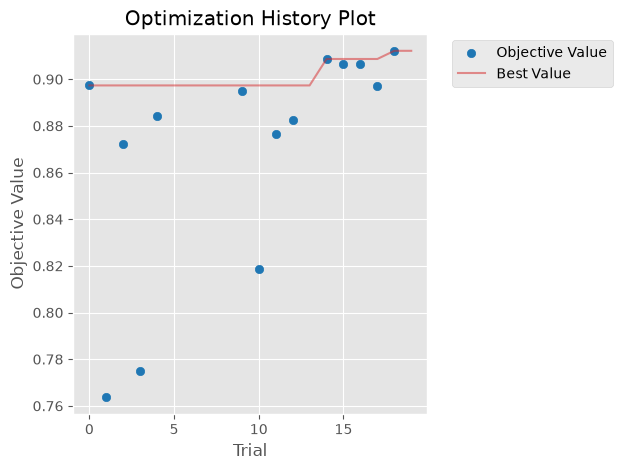

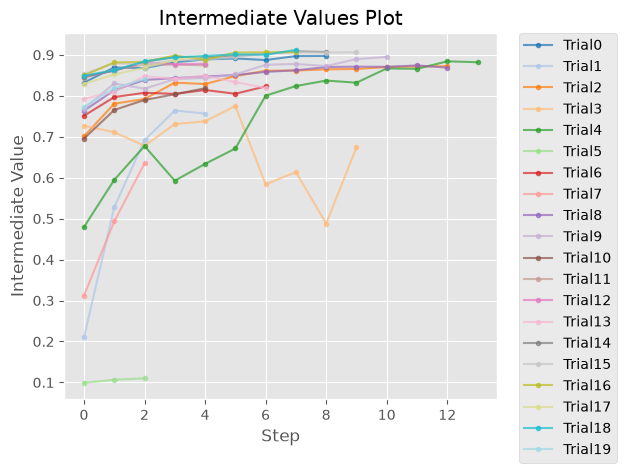

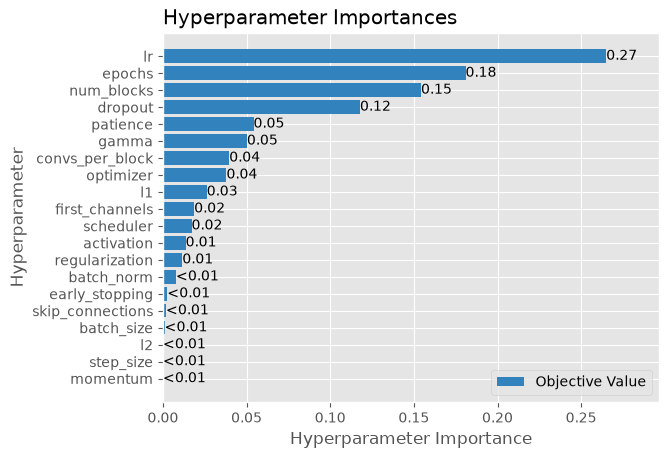

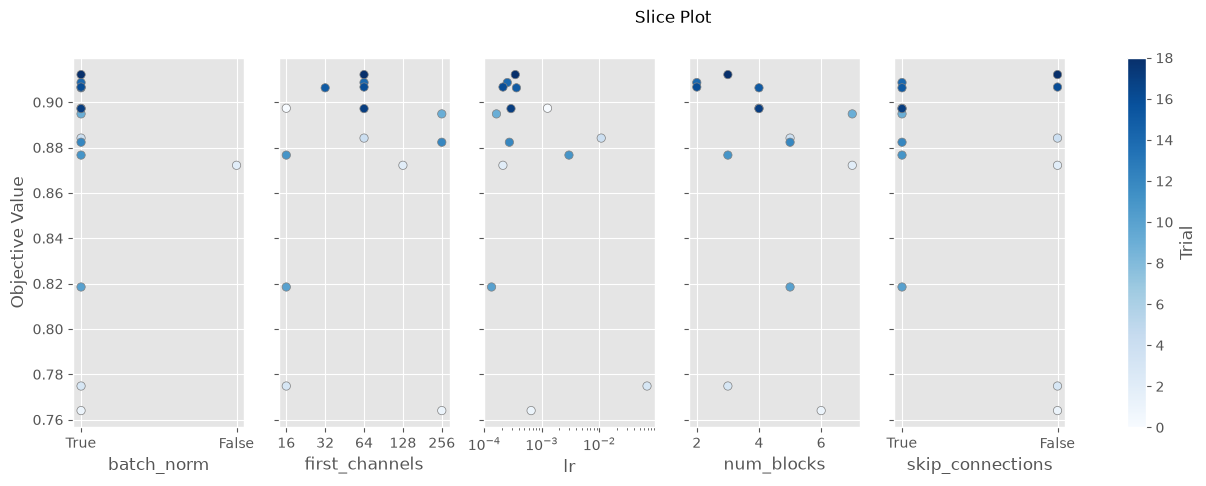

In [7]:
import warnings

import matplotlib.pyplot as plt
import optuna
from optuna.visualization import matplotlib as optuna_plots

# Optuna's matplotlib plots are marked experimental; the warning is not useful here.
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)

optuna_plots.plot_optimization_history(study)
plt.show()
optuna_plots.plot_intermediate_values(study)
plt.show()
optuna_plots.plot_param_importances(study)
plt.show()
optuna_plots.plot_slice(
    study,
    params=["lr", "num_blocks", "first_channels", "batch_norm", "skip_connections"],
)
plt.show()

100%|██████████| 20/20 [00:02<00:00,  9.92it/s]


<Axes: title={'center': 'Terminator Improvement Plot'}, xlabel='Trial', ylabel='Terminator Improvement'>

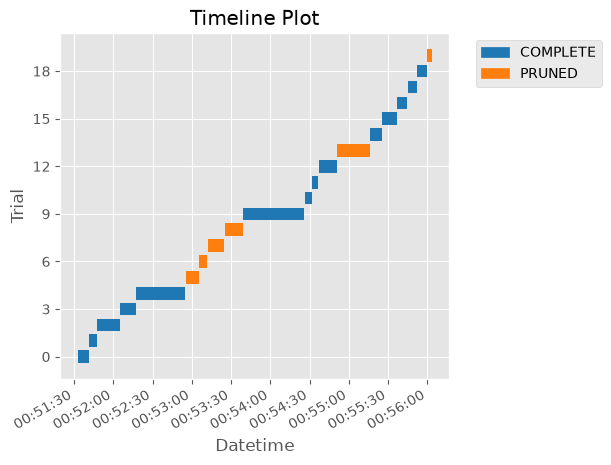

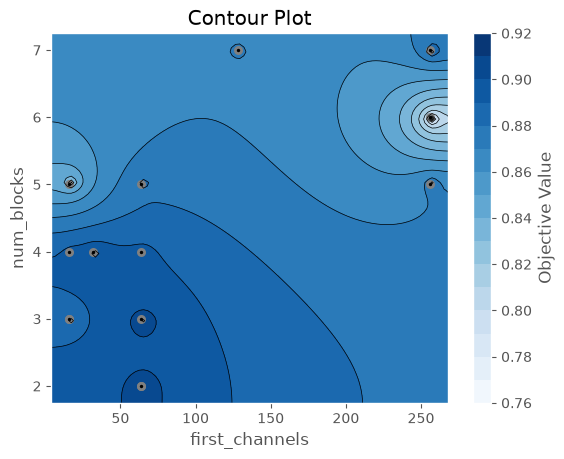

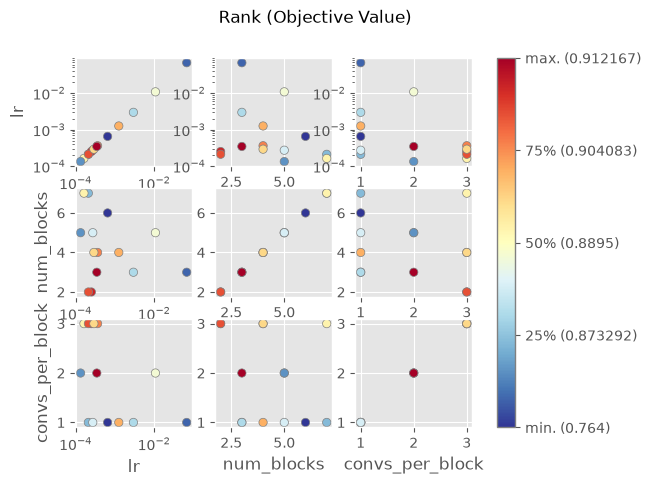

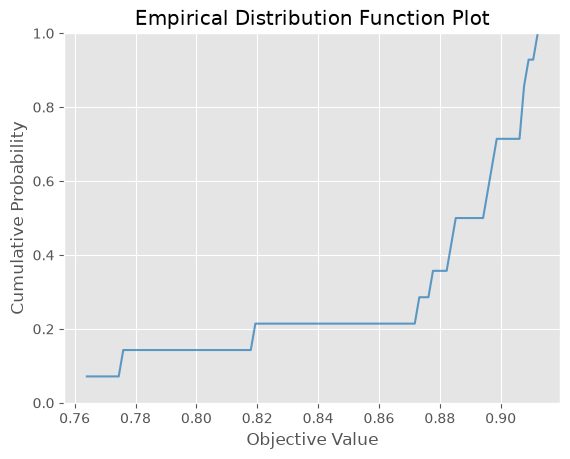

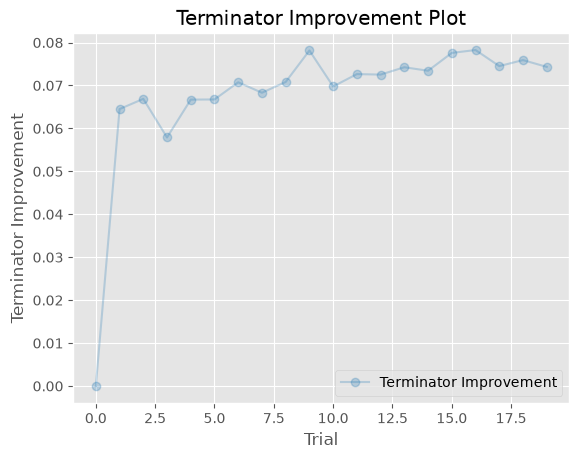

In [8]:
optuna_plots.plot_timeline(study)
optuna_plots.plot_contour(study, params=["num_blocks", "first_channels"])
optuna_plots.plot_rank(study, params=["lr", "num_blocks", "convs_per_block"])
optuna_plots.plot_edf(study)
optuna_plots.plot_terminator_improvement(study)

### See the best network in Netron

[Netron](https://netron.app) draws a network layer by layer. The first cell below builds the network the best trial picked (the `"model"` section of `configs/search01_best.json`, saved by the search) and exports it to **ONNX**, a standard file format for networks. The second cell opens it in Netron, inside the notebook.

- The weights are random: the best config is only trained in section 5. Netron shows the architecture, which does not depend on the weights.
- Click a node to see its settings (kernel size, padding, ...) and the shapes of its weights, e.g. `64×32×3×3` for a convolution from 32 to 64 channels.
- **Skip connections** are the `Add` nodes. One input comes from the block's convolutions; the other comes around them from the block's input: straight for an identity shortcut, through a 1x1 `Conv` (and a `BatchNormalization`) when the channels change.
- **Dropout is not in the graph**: the network is exported in eval mode, where dropout does nothing.
- To compare with the base network, set `best_config_name = "config01.json"` and run both cells again.

Running the second cell again replaces the network shown; `netron.stop(NETRON_PORT)` stops the server. If the frame stays blank, download the `.onnx` file (in Colab, from the study's folder in Drive) and open it at [netron.app](https://netron.app): it runs in your browser, nothing is uploaded.

In [9]:
import json

from HyperparameterSearchConvnets.main import describe
from HyperparameterSearchConvnets.models.components import ConvNet
from HyperparameterSearchConvnets.utils import export_onnx

best_config_name = f"{Path(SEARCH_CONFIG).stem}_best.json"
model_cfg = json.loads((CONFIGS_DIR / best_config_name).read_text())["model"]
net = ConvNet(**model_cfg)
print(f"{describe(model_cfg)}: {sum(p.numel() for p in net.parameters()):,} parameters")

onnx_path = export_onnx(
    net,
    output_dir
    / "HyperparameterSearchConvnets"
    / Path(best_config_name).stem
    / "model.onnx",
)
print(f"Saved {onnx_path}")

3 blocks [64, 128, 256], 2 conv(s) each, BatchNorm: 1,270,602 parameters
Saved /home/virgo/Desktop/projects/CodeCS4337Fall2026/runs/HyperparameterSearchConvnets/search01_best/model.onnx


In [13]:
import netron

NETRON_PORT = 8082

if IN_COLAB:
    from google.colab import output

    # Your browser cannot reach the Colab machine's ports: Colab shows the port in the output.
    netron.start(str(onnx_path), address=("0.0.0.0", NETRON_PORT), browse=False)
    output.serve_kernel_port_as_iframe(NETRON_PORT, height="700")
else:
    from IPython.display import IFrame, display

    netron.start(str(onnx_path), address=("localhost", NETRON_PORT), browse=False)
    print(f"Also open in a browser: http://localhost:{NETRON_PORT}")
    display(IFrame(f"http://localhost:{NETRON_PORT}", width="100%", height=700))

Serving '/home/virgo/Desktop/projects/CodeCS4337Fall2026/runs/HyperparameterSearchConvnets/search01_best/model.onnx' at http://localhost:8082


Also open in a browser: http://localhost:8082


### Optional: the trials in W&B

By default the trials are not logged to W&B: one W&B run per trial makes every trial slower and fills the project with dozens of runs, and the plots above already compare them. To log them, set `"log_trials_to_wandb": true` in the search config's `"study"` before searching. Every trial is then a W&B run in the project `HyperparameterSearchConvnets`, grouped under the search's name (`search01`), with its settings in the run config and `best_val_acc` and `state` (`complete` or `pruned`) in the summary. On wandb.ai:

1. In the **Runs** table, group by `group`, show the columns you care about (`model.channels`, `model.batch_norm`, `model.skip_connections`, `training.lr`, `best_val_acc`, ...), and sort by `best_val_acc`.
2. Add a **Parallel coordinates** panel with the searched settings and `best_val_acc`: one line per trial, so you can follow the best lines back to their settings.
3. Add a **Parameter importance** panel for `best_val_acc`: W&B's own estimate of which settings matter.
4. The `val_acc` and `lr-...` charts overlay all trials, showing what the schedulers and early stopping did.

Without a key, upload the trials later with the `wandb sync` command printed during the search.

## 5. Train the best config

The search saved the best trial's settings as a normal training config, `configs/search01_best.json` (and a copy, `best_config.json`, next to the study in Drive). Its `found_by` entry records which trial it came from.

In [14]:
best_config_name = f"{Path(SEARCH_CONFIG).stem}_best.json"
print((CONFIGS_DIR / best_config_name).read_text())

{
  "seed": 42,
  "accelerator": "auto",
  "wandb": {
    "project": "HyperparameterSearchConvnets"
  },
  "data": {
    "batch_size": 256,
    "val_split": 0.1,
    "num_workers": "auto",
    "train_fraction": 1.0
  },
  "model": {
    "channels": [
      64,
      128,
      256
    ],
    "convs_per_block": 2,
    "batch_norm": true,
    "skip_connections": false,
    "activation": "relu",
    "dropout": 0.15367458028575987
  },
  "training": {
    "epochs": 8,
    "optimizer": "adam",
    "lr": 0.000345742358841534,
    "momentum": 0.9,
    "l1": 2.2555655740657742e-07,
    "l2": 0.0,
    "scheduler": "plateau",
    "step_size": 3,
    "gamma": 0.30225801259970875,
    "early_stopping": true,
    "patience": 5
  },
  "found_by": {
    "search_config": "search01.json",
    "trial": 18,
    "val_acc": 0.9122
  }
}



Train it like any other config: a full run with checkpoints, then **one** evaluation on the test set, which is the score to report. The run is logged to W&B in the group `search01_best`, next to the trials. The same from a terminal: `python -m HyperparameterSearchConvnets --config search01_best.json`.

In [15]:
best_metrics = main(best_config_name)
print(f"Test accuracy of the best config: {best_metrics['test_acc']:.4f}")

Seed set to 42
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Model: 3 blocks [64, 128, 256], 2 conv(s) each, BatchNorm, 1,270,602 parameters


wandb: Currently logged in as: aiwand (txst) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/virgo/Desktop/projects/CodeCS4337Fall2026/.venv/lib/python3.13/site-packages/lightning/fabric/loggers/csv_logs.py:268: Experiment logs directory /home/virgo/Desktop/projects/CodeCS4337Fall2026/runs/HyperparameterSearchConvnets/search01_best/2026-10-03_01-05-08 exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
/home/virgo/Desktop/projects/CodeCS4337Fall2026/.venv/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/virgo/Desktop/projects/CodeCS4337Fall2026/runs/HyperparameterSearchConvnets/search01_best/2026-10-03_01-05-08 exists and is not empty.
LOCAL_RANK: 0 - CU

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ net             │ ConvNet            │  1.3 M │ train │     0 │
│ 1 │ train_metrics   │ MetricCollection   │      0 │ train │     0 │
│ 2 │ train_class_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_metrics     │ MetricCollection   │      0 │ train │     0 │
│ 4 │ val_class_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ test_metrics    │ MetricCollection   │      0 │ train │     0 │
│ 6 │ test_class_acc  │ MulticlassAccuracy │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

...

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9384999871253967     │
│    test_acc_Ankle_boot    │     0.972000002861023     │
│       test_acc_Bag        │    0.9890000224113464     │
│       test_acc_Coat       │    0.9120000004768372     │
│      test_acc_Dress       │    0.9430000185966492     │
│     test_acc_Pullover     │    0.9010000228881836     │
│      test_acc_Sandal      │    0.9860000014305115     │
│      test_acc_Shirt       │    0.7860000133514404     │
│     test_acc_Sneaker      │    0.9850000143051147     │
│   test_acc_T-shirt_top    │     0.921999990940094     │
│     test_acc_Trouser      │    0.9890000224113464     │
│         test_loss         │    0.18754498660564423    │
│      test_precision       │    0.9383900165557861     │
│        test_recall        │    0.9385000467300415     │
└───────────────────────────┴───────────────────────────┘

W&B run: https://wandb.ai/txst/HyperparameterSearchConvnets/runs/9jg0acny


epoch,▁▁▂▂▃▃▄▄▅▅▅▅▆▆▇▇█
lr-Adam,██████▁▁
test_acc,▁
test_acc_Ankle_boot,▁
test_acc_Bag,▁
test_acc_Coat,▁
test_acc_Dress,▁
test_acc_Pullover,▁
test_acc_Sandal,▁
test_acc_Shirt,▁
+35,...


Test accuracy of the best config: 0.9385


**Compare with the starting point** (optional): `config01.json` holds the default settings (Adam, learning rate 0.001, 10 epochs, and the plain two-block ConvNet `[32, 64]` with one convolution per block and no BatchNorm, skip connections, or dropout). Did the search beat it on the test set?

In [16]:
baseline_metrics = main("config01.json")
print(
    f"Baseline {baseline_metrics['test_acc']:.4f}, best config {best_metrics['test_acc']:.4f}"
)

Seed set to 42


Model: 2 blocks [32, 64], 1 conv(s) each, 50,186 parameters


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/virgo/Desktop/projects/CodeCS4337Fall2026/.venv/lib/python3.13/site-packages/lightning/fabric/loggers/csv_logs.py:268: Experiment logs directory /home/virgo/Desktop/projects/CodeCS4337Fall2026/runs/HyperparameterSearchConvnets/config01/2026-10-03_01-10-12 exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
/home/virgo/Desktop/projects/CodeCS4337Fall2026/.venv/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/virgo/Desktop/projects/CodeCS4337Fall2026/runs/HyperparameterSearchConvnets/config01/2026-10-03_01-10-12 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ net             │ ConvNet            │ 50.2 K │ train │     0 │
│ 1 │ train_metrics   │ MetricCollection   │      0 │ train │     0 │
│ 2 │ train_class_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_metrics     │ MetricCollection   │      0 │ train │     0 │
│ 4 │ val_class_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ test_metrics    │ MetricCollection   │      0 │ train │     0 │
│ 6 │ test_class_acc  │ MulticlassAccuracy │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 50.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 50.2 K                                                                                               
Total estimated model params size (MB): 0.201                                                                      
Modules in train mode: 32                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9061999917030334     │
│    test_acc_Ankle_boot    │    0.9459999799728394     │
│       test_acc_Bag        │    0.9850000143051147     │
│       test_acc_Coat       │    0.9490000009536743     │
│      test_acc_Dress       │    0.8669999837875366     │
│     test_acc_Pullover     │    0.8119999766349792     │
│      test_acc_Sandal      │    0.9779999852180481     │
│      test_acc_Shirt       │    0.6759999990463257     │
│     test_acc_Sneaker      │    0.9829999804496765     │
│   test_acc_T-shirt_top    │    0.8870000243186951     │
│     test_acc_Trouser      │    0.9789999723434448     │
│         test_loss         │    0.26148900389671326    │
│      test_precision       │    0.9096181988716125     │
│        test_recall        │    0.9062000513076782     │
└───────────────────────────┴───────────────────────────┘

W&B run: https://wandb.ai/txst/HyperparameterSearchConvnets/runs/jls2qp4t


epoch,▁▁▂▂▂▂▃▃▄▄▅▅▅▅▆▆▇▇▇▇█
lr-Adam,▁▁▁▁▁▁▁▁▁▁
test_acc,▁
test_acc_Ankle_boot,▁
test_acc_Bag,▁
test_acc_Coat,▁
test_acc_Dress,▁
test_acc_Pullover,▁
test_acc_Sandal,▁
test_acc_Shirt,▁
+35,...


Baseline 0.9062, best config 0.9385


## 6. Look inside the trained model with Captum

[Captum](https://captum.ai) is PyTorch's library for explaining what a model does. This section loads the best config's trained model (section 5) and shows:

1. **Activation maps:** what every convolution layer outputs, after its ReLU, for one test image.
2. **Grad-CAM:** which parts of an image made the model choose its class, for 10 test images of every class.

The model is loaded back from its run folder, so this section works after a runtime reset without training again. `load_model("search01_best")` takes the newest run in `<OUTPUT_DIR>/HyperparameterSearchConvnets/search01_best/`, rebuilds the network the search picked from that run's `config.json`, and loads its **best** checkpoint. To use one specific run, pass its folder instead, e.g. `load_model("search01_best/2026-10-03_01-05-08")`.

**Before this section:** a finished `search01_best` run (section 5); in Colab, section 1 with Drive mounted; then the first two cells of section 2.

In [3]:
import os

import matplotlib.pyplot as plt
import torch
from dotenv import load_dotenv
from torchvision import datasets, transforms

from HyperparameterSearchConvnets import load_model
from HyperparameterSearchConvnets.dataloaders.fashion_mnist import (
    FASHION_MNIST_MEAN,
    FASHION_MNIST_STD,
)

RUN = "search01_best"  # the newest run of this config, or one run folder

model = load_model(RUN)
net = model.net.eval()
channels = [block.conv_layers[0].out_channels for block in net.blocks]
print(f"{len(net.blocks)} blocks, channels {channels}")

load_dotenv(REPO / ".env")
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize(FASHION_MNIST_MEAN, FASHION_MNIST_STD)]
)
test_set = datasets.FashionMNIST(
    REPO / os.getenv("DATA_DIR", "data"), train=False, download=True, transform=transform
)


def to_pixels(image: torch.Tensor) -> torch.Tensor:
    """Undo the normalization, to show an image as it looks."""
    return image.squeeze() * FASHION_MNIST_STD[0] + FASHION_MNIST_MEAN[0]

Loaded /home/virgo/Desktop/projects/CodeCS4337Fall2026/runs/HyperparameterSearchConvnets/search01_best/2026-10-03_01-05-08/best_epoch07_valacc0.9447.ckpt
3 blocks, channels [64, 128, 256]


In [8]:
from torchinfo import summary

summary(
    model,
    input_size=(1, 1, 28, 28),
    col_names=(
        "input_size",
        "output_size",
        "kernel_size",
        "num_params",
        "mult_adds",
        "trainable",)
)

Layer (type:depth-idx)                        Input Shape               Output Shape              Kernel Shape              Param #                   Mult-Adds                 Trainable
LitConvNet                                    [1, 1, 28, 28]            [1, 10]                   --                        --                        --                        True
├─ConvNet: 1-1                                [1, 1, 28, 28]            [1, 10]                   --                        --                        --                        True
│    └─Sequential: 2-1                        [1, 1, 28, 28]            [1, 256, 7, 7]            --                        --                        --                        True
│    │    └─ConvBlock: 3-1                    [1, 1, 28, 28]            [1, 64, 14, 14]           --                        37,696                    29,353,216                True
│    │    └─ConvBlock: 3-2                    [1, 64, 14, 14]           [1, 128, 7, 7]    

> FLOPs are approximately 2 × MACs (model computational workload) / Mult-Adds when multiplication and addition are counted separately.

### Activation maps after every ReLU

Every convolution in a block is followed by an activation (ReLU, unless the search picked another one); in the last convolution of a block, it comes after the skip connection's addition. Captum's `LayerActivation` records the output of each of these activations for one test image. A layer outputs one 2-D map per channel (one per filter), bright where that filter responded; each row shows **8 channels picked at random** (`CHANNEL_SEED` fixes which, so you can compare runs). The label of a row gives the layer and its output size: channels × height × width.

What to look for:

- **Dark areas** are zeros: ReLU sets every negative value to zero, so only the places where a filter responded stay.
- The **first layers** keep the image's shape and respond to simple patterns: edges in one direction, bright or dark areas.
- After each of the first two blocks, **max pooling** halves the height and width (28 → 14 → 7): later maps are coarser, and their channels respond to larger parts of the item (a sleeve, a heel, a collar).
- Some channels are **all dark** for this image: those filters look for something it does not have.

Change `INDEX` to look at another test image.

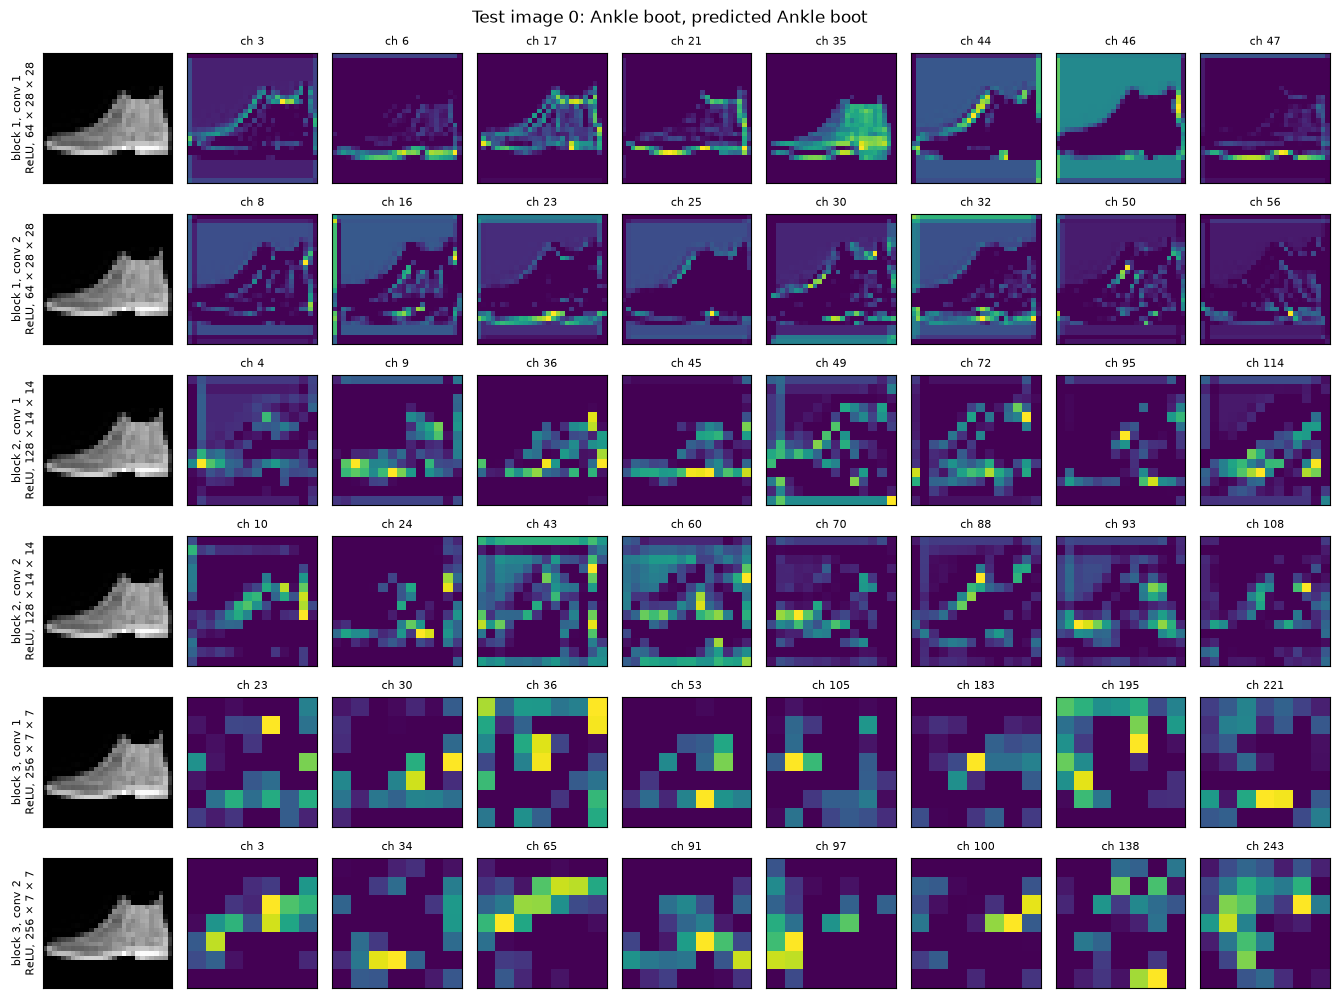

In [4]:
from captum.attr import LayerActivation

from HyperparameterSearchConvnets.models.components.convnet import ACTIVATIONS

INDEX = 0  # which test image
N_CHANNELS = 8  # channels shown per layer, picked at random
CHANNEL_SEED = 0

# The activation after each convolution: inside conv_layers, then the block's last one.
activation_types = tuple(ACTIVATIONS.values())
relu_layers = {}
for b, block in enumerate(net.blocks, start=1):
    inner = [m for m in block.conv_layers if isinstance(m, activation_types)]
    for c, layer in enumerate([*inner, block.activation], start=1):
        relu_layers[f"block {b}, conv {c}"] = layer

image, label = test_set[INDEX]
x = image.unsqueeze(0)
with torch.no_grad():
    pred = net(x).argmax(dim=1).item()
activations = LayerActivation(net, list(relu_layers.values())).attribute(x)

generator = torch.Generator().manual_seed(CHANNEL_SEED)
fig, axes = plt.subplots(
    len(relu_layers),
    N_CHANNELS + 1,
    figsize=(1.5 * (N_CHANNELS + 1), 1.7 * len(relu_layers)),
    squeeze=False,
)
for row, (name, layer), activation in zip(axes, relu_layers.items(), activations):
    activation = activation[0].detach()  # (channels, height, width)
    picked = torch.randperm(len(activation), generator=generator)[:N_CHANNELS].sort().values
    size = " × ".join(map(str, activation.shape))
    row[0].imshow(to_pixels(image), cmap="gray")
    row[0].set_ylabel(f"{name}\n{type(layer).__name__}, {size}", fontsize=8)
    for ax, channel in zip(row[1:], picked):
        ax.imshow(activation[channel], cmap="viridis")
        ax.set_title(f"ch {channel.item()}", fontsize=8)
    for ax in row:
        ax.set_xticks([])
        ax.set_yticks([])
fig.suptitle(
    f"Test image {INDEX}: {test_set.classes[label]}, predicted {test_set.classes[pred]}"
)
fig.tight_layout()
plt.show()

### Grad-CAM: 10 test images of every class

Grad-CAM (*Gradient-weighted Class Activation Mapping*) answers "where did the model look?" for the class it predicted. Captum's `LayerGradCam` computes it from one layer:

1. Take the layer's output: one map per channel, as above.
2. Compute the **gradient** of the predicted class's score with respect to that output, and average it over each map: one weight per channel, large when the channel pushes the score up.
3. Add up the maps, each multiplied by its weight, and keep the positive part. The result is a heatmap at the layer's resolution, which `LayerAttribution.interpolate` scales up to 28 × 28 to lay it over the image.

Each row below is one class, with its first 10 test images. **Red** areas raised the score of the predicted class the most. A wrong prediction has a red frame and the predicted class above it: does its heatmap show a part that also fits that class?

**Which layer?** `CAM_BLOCK = 2` explains the output of block 2's last activation (before its pooling), the last layer at 14 × 14. Try `CAM_BLOCK = 1` (finer, 28 × 28, but it mostly marks edges) and the last block, `CAM_BLOCK = len(net.blocks)` (7 × 7). Grad-CAM is usually computed at the last convolution layer, but here many of its heatmaps come out **empty**: this network's head flattens the 7 × 7 maps into a `Linear` layer (no global average pooling, unlike ResNet), so a channel's gradient is positive in some places and negative in others, and its average, the channel's weight, often cancels out.|

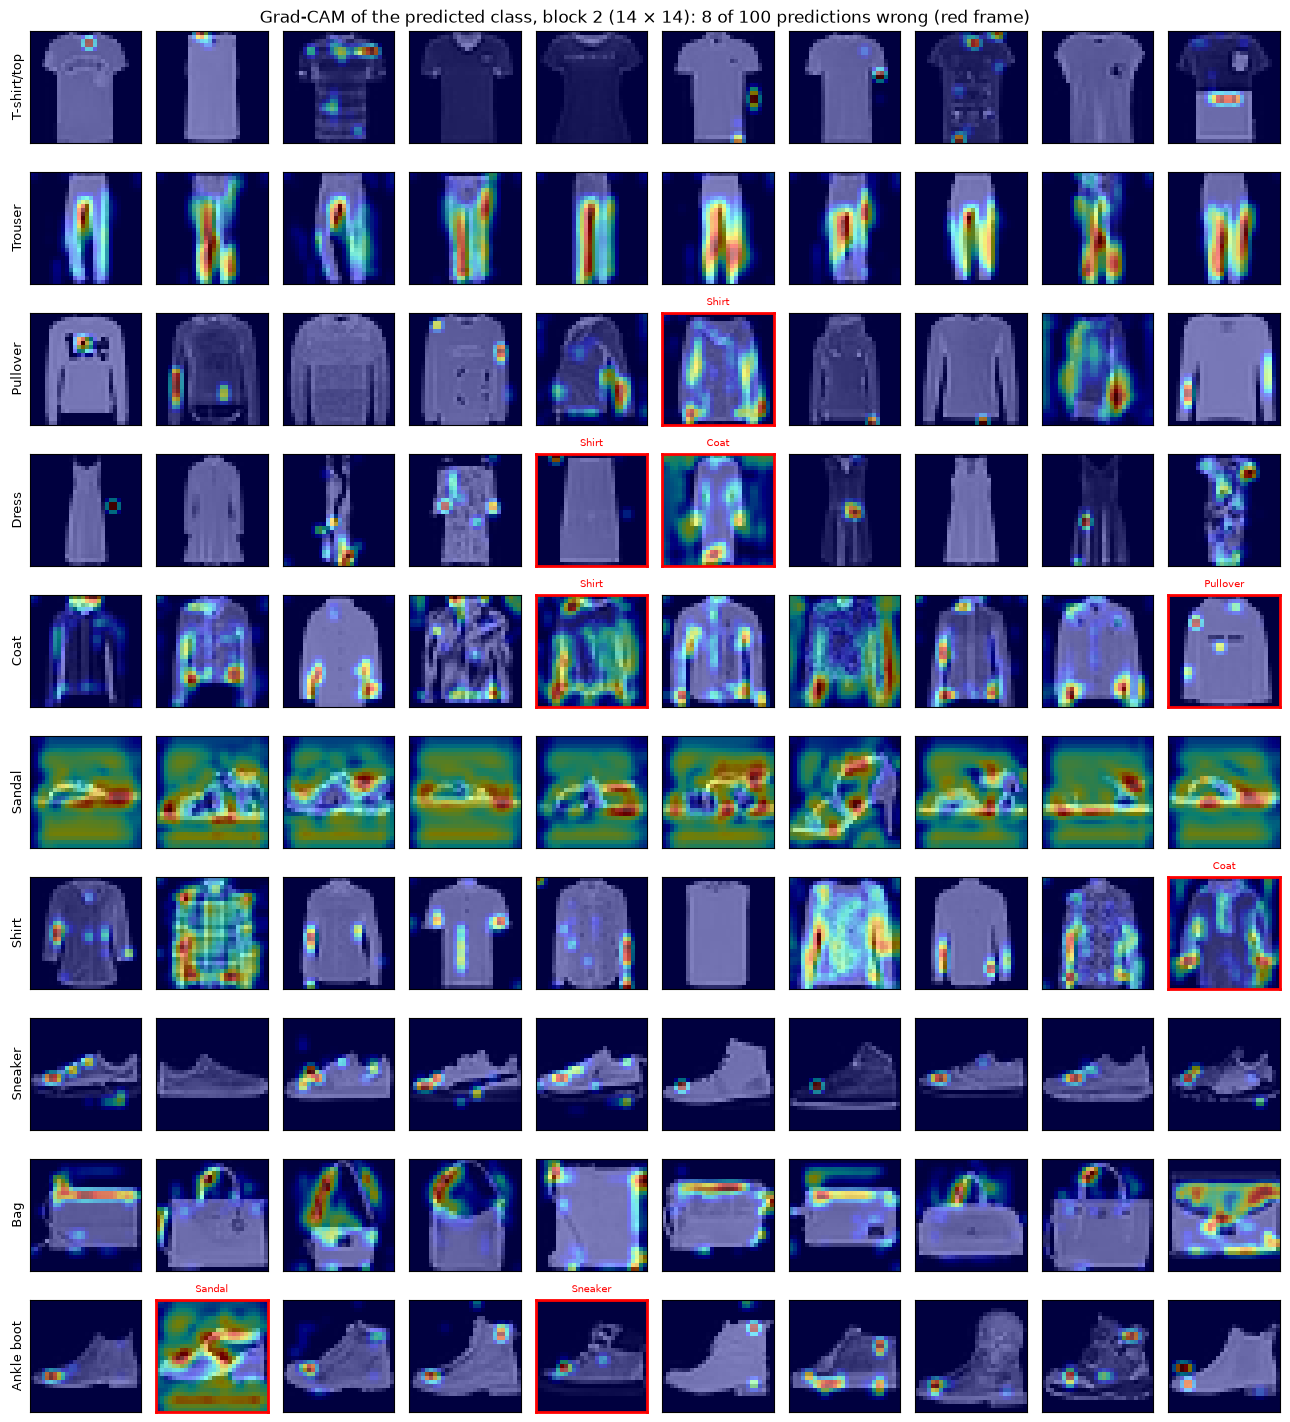

In [5]:
from captum.attr import LayerAttribution, LayerGradCam

N_PER_CLASS = 10
CAM_BLOCK = 2  # 1 = first block; len(net.blocks) = last block

classes = test_set.classes
indices = torch.cat(
    [(test_set.targets == c).nonzero()[:N_PER_CLASS, 0] for c in range(len(classes))]
)
images = torch.stack([test_set[i][0] for i in indices])
labels = test_set.targets[indices]
with torch.no_grad():
    preds = net(images).argmax(dim=1)

layer = net.blocks[CAM_BLOCK - 1].activation
# The predicted class of each image is the one explained.
cam = LayerGradCam(net, layer).attribute(images, target=preds, relu_attributions=True)
height, width = cam.shape[-2:]
cam = LayerAttribution.interpolate(cam, images.shape[-2:], interpolate_mode="bilinear")

fig, axes = plt.subplots(
    len(classes), N_PER_CLASS, figsize=(1.3 * N_PER_CLASS, 1.45 * len(classes))
)
for ax, image, heatmap, pred, label in zip(axes.flat, images, cam.detach(), preds, labels):
    ax.imshow(to_pixels(image), cmap="gray")
    ax.imshow(heatmap[0], cmap="jet", alpha=0.5)
    ax.set_xticks([])
    ax.set_yticks([])
    if pred != label:
        ax.set_title(classes[pred], fontsize=7, color="red")
        for spine in ax.spines.values():
            spine.set_color("red")
            spine.set_linewidth(2)
for ax, name in zip(axes[:, 0], classes):
    ax.set_ylabel(name, fontsize=9)
wrong = (preds != labels).sum().item()
fig.suptitle(
    f"Grad-CAM of the predicted class, block {CAM_BLOCK} ({height} × {width}): "
    f"{wrong} of {len(images)} predictions wrong (red frame)"
)
fig.tight_layout()
plt.show()

## Tips

**Long searches in Colab**
- The study is saved in Google Drive (`MyDrive/CodeCS4337Fall2026/runs/HyperparameterSearchConvnets/search01/study.db`) after every trial. After a disconnect, re-run the setup cells and the search cell: the finished trials are kept and new ones are added.
- `configs/search01_best.json` is in `/content`, which is deleted when the runtime resets. Get it back with the reload cell (`n_trials=0`), which rewrites it from the study.
- Set `timeout_minutes` in the search config to stop starting new trials after a time limit.
- The [pro tips in the main README](https://github.com/TXSTCODEPLAYGROUND/CodeCS4337Fall2026#pro-tips-keep-training-running) (idle disconnects, GPU quota) apply here too.

**Searching well**
- Start wide, then narrow: after a first search, read the importances and slice plots, fix the unimportant hyperparameters, and search the important ones in a smaller range (`search02.json`).
- To start a search over, use a new search config name, or delete its folder in Drive.
- Fewer epochs per trial make the search faster, but favor settings that learn fast rather than settings that end best.

## Training with the Colab CLI

Another way to train this project, once everything is final. Its only purpose
is the training run itself:

1. **Work locally** on the project: change the code or a config, run short
   tests, fix bugs.
2. **Use Google Colab** (this notebook) for debugging and interactive work.
3. **Use the Colab CLI** when everything is final and the only thing left is
   training. The CLI creates a Colab runtime from your local terminal and opens
   a shell on it, so there is no notebook or browser tab to keep open. On the
   runtime you clone the repo and run `python -m HyperparameterSearchConvnets.search --config search01.json`.

The Colab CLI works on Linux and macOS (not Windows). For more detail, see
[google-colab-cli.md](https://github.com/TXSTCODEPLAYGROUND/CodeCS4337Fall2026/blob/main/google-colab-cli.md) at the repo root or the
[official Colab CLI documentation](https://github.com/googlecolab/google-colab-cli).

### Step 1: Install the CLI

On your own machine:

```bash
uv tool install google-colab-cli     # or: pip install google-colab-cli
colab version                         # check that it works
```

The first command that talks to Colab prints a sign-in link: open it, sign in
with your Google account, and paste the code it shows back into the terminal.

### Step 2: The basic workflow (sessions)

A **session** is one Colab runtime (a virtual machine) with a name you choose,
here `cs4337`. These commands run in your **local** terminal:

| What | Command |
| --- | --- |
| Create a session with a GPU | `colab new -s cs4337 --gpu T4` (or `L4`, `A100`, `H100`, depending on your plan) |
| Create a session without a GPU | `colab new -s cs4337` (CPU only) |
| List your sessions / check one | `colab sessions` / `colab status -s cs4337` |
| Attach to a session (open a shell on it) | `colab ssh -s cs4337` |
| Leave the shell; the session keeps running | `exit` |
| Stop the session (delete the runtime) | `colab stop -s cs4337` |

Use a GPU runtime: `--gpu T4` is enough for this project. A CPU session can't be switched to a GPU: stop it and create a new one.

> **Once a session is stopped, nothing on it stays.** The cloned repo, the
> downloaded data, and every file that is not on Google Drive are deleted.
> This project writes its runs to Google Drive (step 4), so mount Drive before
> training.

### Step 3: Mount Google Drive

Drive is mounted from your local terminal, not from inside the session. If you
are attached, `exit` first:

```bash
exit                                # only if you are inside the session
colab drivemount -s cs4337          # open the link it prints and allow access
colab ssh -s cs4337                 # attach again
ls /content/drive/MyDrive           # check: your Drive files are listed
```

### Step 4: Clone the repo and train

Inside the session, clone the repo and go to its root folder:

```bash
cd /content
git clone https://github.com/TXSTCODEPLAYGROUND/CodeCS4337Fall2026.git
cd CodeCS4337Fall2026
cp .envcolab .env
```

The runtime only sees what is on GitHub: if you changed code or a config
locally, push it to your own fork first and clone that instead. `.envcolab`
sets `DATA_DIR=/content/data` (data on the runtime's fast local disk) and
`OUTPUT_DIR=/content/drive/MyDrive/CodeCS4337Fall2026/runs` (runs on Drive, so they are kept after a stop).

This project logs to Weights & Biases and reads the key only from `.env`.
Add your W&B API key (from [wandb.ai/authorize](https://wandb.ai/authorize))
to the runtime's `.env`. `read -s` hides the key while you paste it, so it is
not shown on screen or saved in the shell history:

```bash
read -rsp "W&B API key: " key && echo "WANDB_API_KEY=$key" >> .env && unset key && echo
```

Without a key the run still trains, but W&B logs offline into the run folder;
upload it later with the `wandb sync` command that the run prints. Never put
the key in `.envcolab`, which is in git.

Install only the packages Colab doesn't already have, as the setup of this notebook
does. A plain `pip install -r requirements.txt` would replace Colab's own
versions, which is slow and can break other preinstalled packages:

```bash
grep -vE '^\s*(#|$)' requirements.txt \
  | sed -E 's/[<>=!~;[ ].*//' \
  | while read -r pkg; do
      if pip show "$pkg" > /dev/null 2>&1; then echo "skip $pkg (already installed)"
      else pip install -q "$pkg" && echo "installed $pkg"; fi
    done
```

Start a `tmux` session first, so the search keeps going if the SSH connection
drops or you close your laptop. Then, from the repo root, run the search and
train the best config it finds, one after the other:

```bash
tmux new -s train                  # if tmux is missing: apt-get install -y tmux
python -m HyperparameterSearchConvnets.search --config search01.json \
  && python -m HyperparameterSearchConvnets --config search01_best.json
```

The search saves the best config as `configs/search01_best.json` inside the
cloned repo, which is deleted when the session stops. Its study (`study.db`)
and `trials.csv` are on Drive, though: if the session stopped before the final
training, clone again and run
`python -m HyperparameterSearchConvnets.search --config search01.json --n-trials 0` to write
`search01_best.json` back without running any new trial. Running the same
search command again (without `--n-trials 0`) continues the saved study.

To leave training running, press `Ctrl+B`, then `D`. To come back later:
`colab ssh -s cs4337`, then `tmux attach -t train`.

### Step 5: Check that everything was logged

The run folders are on Google Drive, so they are kept after the session
stops. From the session:

```bash
ls /content/drive/MyDrive/CodeCS4337Fall2026/runs/HyperparameterSearchConvnets/search01_best
```

or on [drive.google.com](https://drive.google.com), under **My Drive >
CodeCS4337Fall2026 > runs > HyperparameterSearchConvnets**. Check that:

- each run has its own `<timestamp>` folder (the path is printed when the run starts), with its config, results, plots, and checkpoints;
- `runs_summary.csv`, next to the run folders, has one new row per run;
- `/content/drive/MyDrive/CodeCS4337Fall2026/runs/HyperparameterSearchConvnets/search01/` has the search's `trials.csv` and `study.db`;
- the run shows up in your W&B project: the run prints its W&B link. If it printed a `wandb sync` command instead, the run was logged offline (no key or no login); run that command later, from a machine with your key, to upload it;
- if the session stopped or the run was cut off, start a new session, repeat the steps above, and continue from the last checkpoint on Drive with `--resume-from search01_best`, e.g. `python -m HyperparameterSearchConvnets --config search01_best.json --resume-from search01_best`.

When everything is checked, stop the session so it no longer uses your Colab
quota:

```bash
colab stop -s cs4337
```